<a href="https://colab.research.google.com/github/hanhanwu/Hanhan_COLAB_Experiemnts/blob/master/GenAI_Practice/multimodal/Try_PixelRAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Try PixelRAG on PDF Data

* Using Vectara data: https://huggingface.co/datasets/vectara/open_ragbench

In [ ]:
!pip install huggingface_hub PyMuPDF Pillow requests -q

# The original image display code (from cell o83kIS-RCKR7) was:
# img_bytes = base64.b64decode(img_b64)
# It didn't display the image because img_b64 contained a data URI prefix.
# The fix is to split the string and take only the base64 part:
# img_bytes = base64.b64decode(img_b64.split(',')[1])

# To apply this fix, please update the line in cell o83kIS-RCKR7 directly.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 53.5 MB/s eta 0:00:00


### Load Data Input

In [ ]:
from huggingface_hub import snapshot_download
import os

# Downloads ~743 MB — PDFs + all JSON files
# Set local_dir to wherever you want it in Colab
repo_dir = snapshot_download(
    repo_id="vectara/open_ragbench",
    repo_type="dataset",
    local_dir="/content/open_ragbench",
    ignore_patterns=["*.gitattributes"]
)

print(f"Downloaded to: {repo_dir}")
!ls /content/open_ragbench/official/pdf/arxiv/

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching ... files: 0it [00:00, ?it/s]

Downloaded to: /content/open_ragbench
ls: cannot access '/content/open_ragbench/official/pdf/arxiv/': No such file or directory


### Explore Data Input

In [ ]:
import json, os

base = "/content/open_ragbench/pdf/arxiv"

# --- queries.json: all QA pairs ---
with open(f"{base}/queries.json") as f:
    queries = json.load(f)

# --- qrels.json: query → paper_id relevance labels ---
with open(f"{base}/qrels.json") as f:
    qrels = json.load(f)

# --- pdf_urls.json: original arXiv PDF URLs ---
with open(f"{base}/pdf_urls.json") as f:
    pdf_urls = json.load(f)

print(f"Total queries: {len(queries)}")
print(f"Total qrels:   {len(qrels)}")
print(f"Total PDFs:    {len(pdf_urls)}")

# Peek at query types (text / text-table / text-image / text-table-image)
from collections import Counter
source_counts = Counter(v["source"] for v in queries.values())
print("\nQuery sources:", source_counts)

Total queries: 3045
Total qrels:   3045
Total PDFs:    1000

Query sources: Counter({'text': 1914, 'text-image': 763, 'text-table-image': 220, 'text-table': 148})


**Pick the first paper that has BOTH tables and images**

In [ ]:
import json, os, base64
from IPython.display import display, Image, HTML

corpus_dir = "/content/open_ragbench/pdf/arxiv/corpus"
paper_files = os.listdir(corpus_dir)

# Pick the first paper that has BOTH tables and images
target_paper = None
for fname in paper_files:
    with open(os.path.join(corpus_dir, fname)) as f:
        doc = json.load(f)
    has_table = any(s.get("tables") for s in doc["sections"])
    has_img   = any(s.get("images") for s in doc["sections"])
    if has_table and has_img:
        target_paper = doc
        break

print(f"Paper: {target_paper['title']}")
print(f"Authors: {', '.join(target_paper['authors'][:3])}...")
print(f"Categories: {target_paper['categories']}")
print(f"Sections: {len(target_paper['sections'])}")

Paper: FGBERT: Function-Driven Pre-trained Gene Language Model for Metagenomics
Authors: ChenRui Duan, Zelin Zang, Yongjie Xu...
Categories: ['q-bio.GN', 'cs.AI', 'cs.LG']
Sections: 25


In [ ]:
from IPython.display import display, HTML

# Find first section with a table
for section in target_paper["sections"]:
    if section.get("tables"):
        table_md = list(section["tables"].values())[0]

        # Convert markdown table → basic HTML for display
        rows = [r.strip() for r in table_md.strip().split("\n") if r.strip()]
        html = '<table border="1" style="border-collapse:collapse;font-size:12px">'
        for i, row in enumerate(rows):
            if "---" in row: continue  # skip separator
            tag = "th" if i == 0 else "td"
            cells_row = [c.strip() for c in row.strip("|").split("|")]
            html += "<tr>" + "".join(f"<{tag} style='padding:4px 8px'>{c}</{tag}>" for c in cells_row) + "</tr>"
        html += "</table>"

        display(HTML(f"<h4>Table from: {target_paper['title'][:60]}...</h4>" + html))
        break

Task,Dataset,Description,\#Seq.,\#Class
:--:,:--:,:--:,:--:,:--:
Gene Structure Prediction (Gene Level),E-K12,Gene Operons,"4,315","1,379"
Functional Prediction (Functional Level),CARD-A,AMR Family,"1,966",269
,CARD-D,Drug Class,"1,966",37
,CARD-R,Resistance Mech.,"1,966",7
,VFDB,Virulence Fact.,"8,945",15
,ENZYME,Enzyme Func.,"5,761",7
Pathogenicity Prediction (Bacteria Level),PATRIC,Pathogenic Genes,"5,000",110
Nitrogen Cycle Prediction (Environmental Level),NCycDB,Cycling Genes,"213,501",68


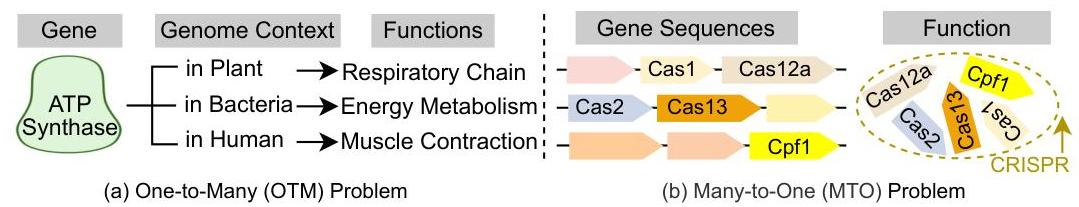

In [ ]:
import base64
from IPython.display import Image, display

# Find first section with an image
for section in target_paper["sections"]:
    if section.get("images"):
        img_b64 = list(section["images"].values())[0]
        img_bytes = base64.b64decode(img_b64.split(',')[1])
        display(Image(data=img_bytes, width=780))
        break

Downloading: https://arxiv.org/pdf/2402.16901v2
--- Page 1 ---


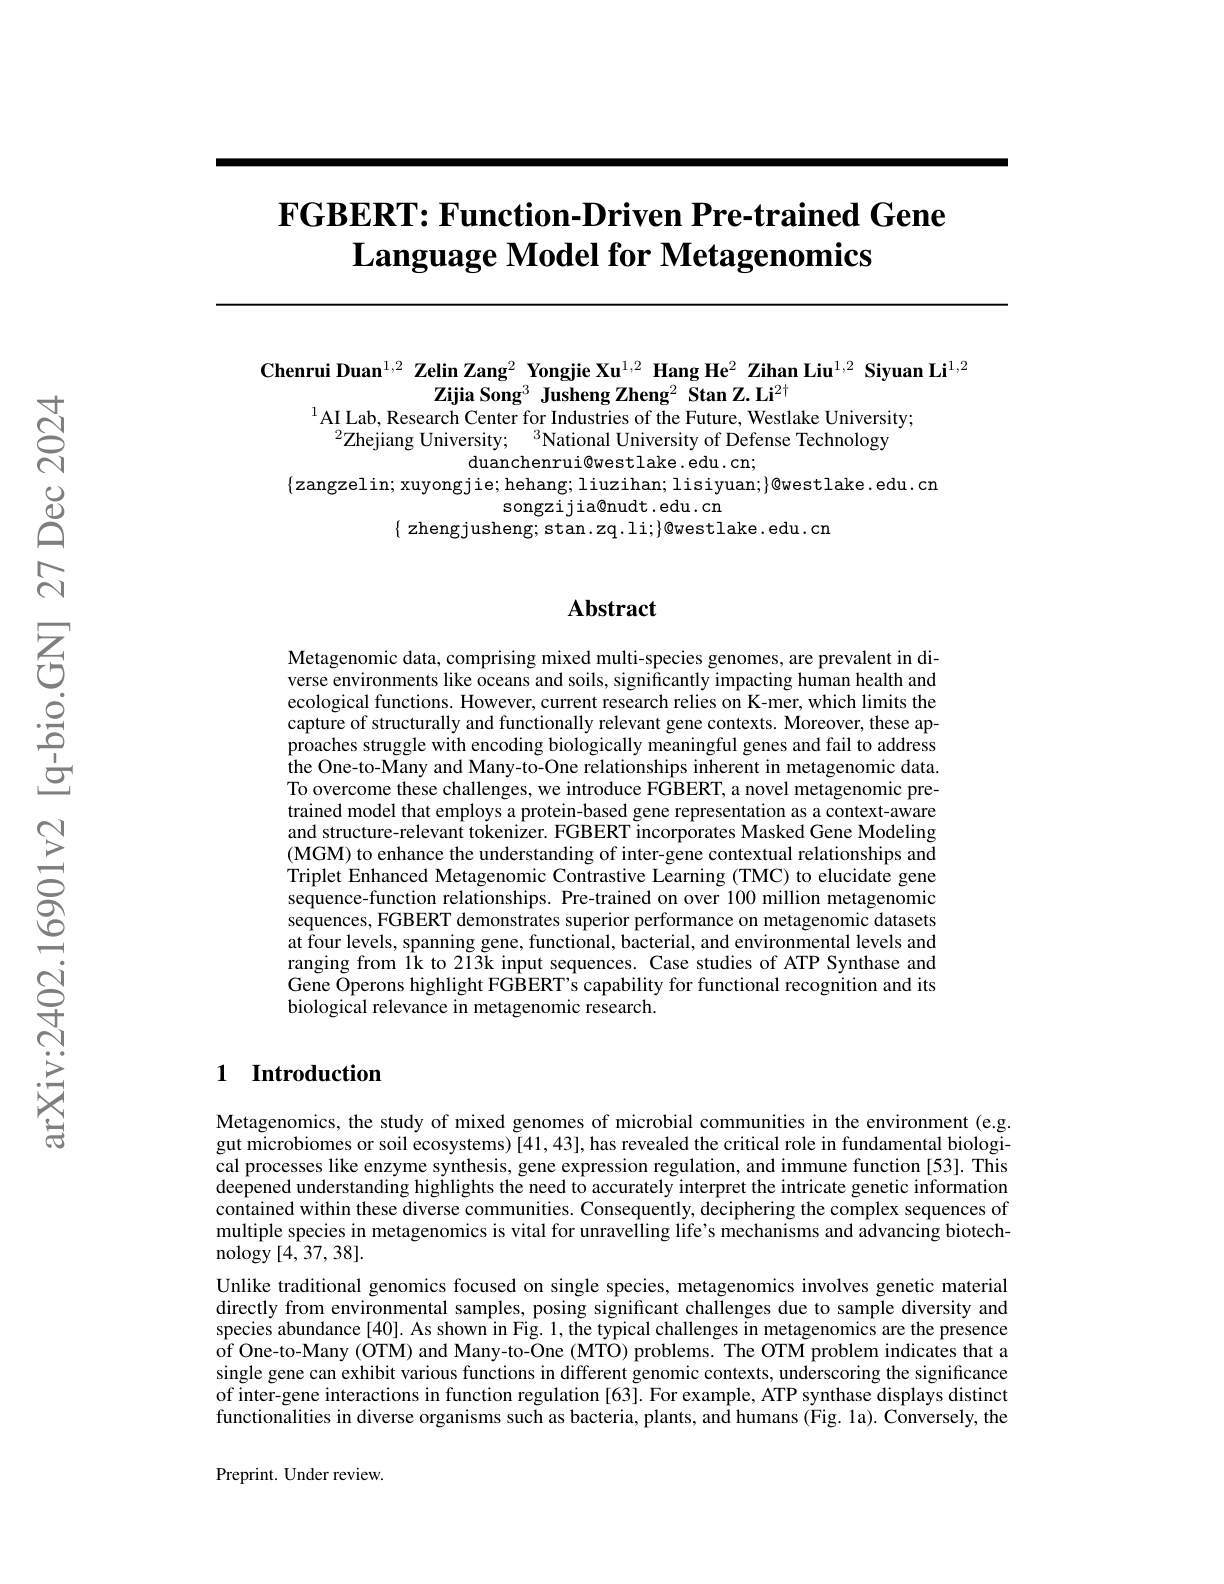

--- Page 2 ---


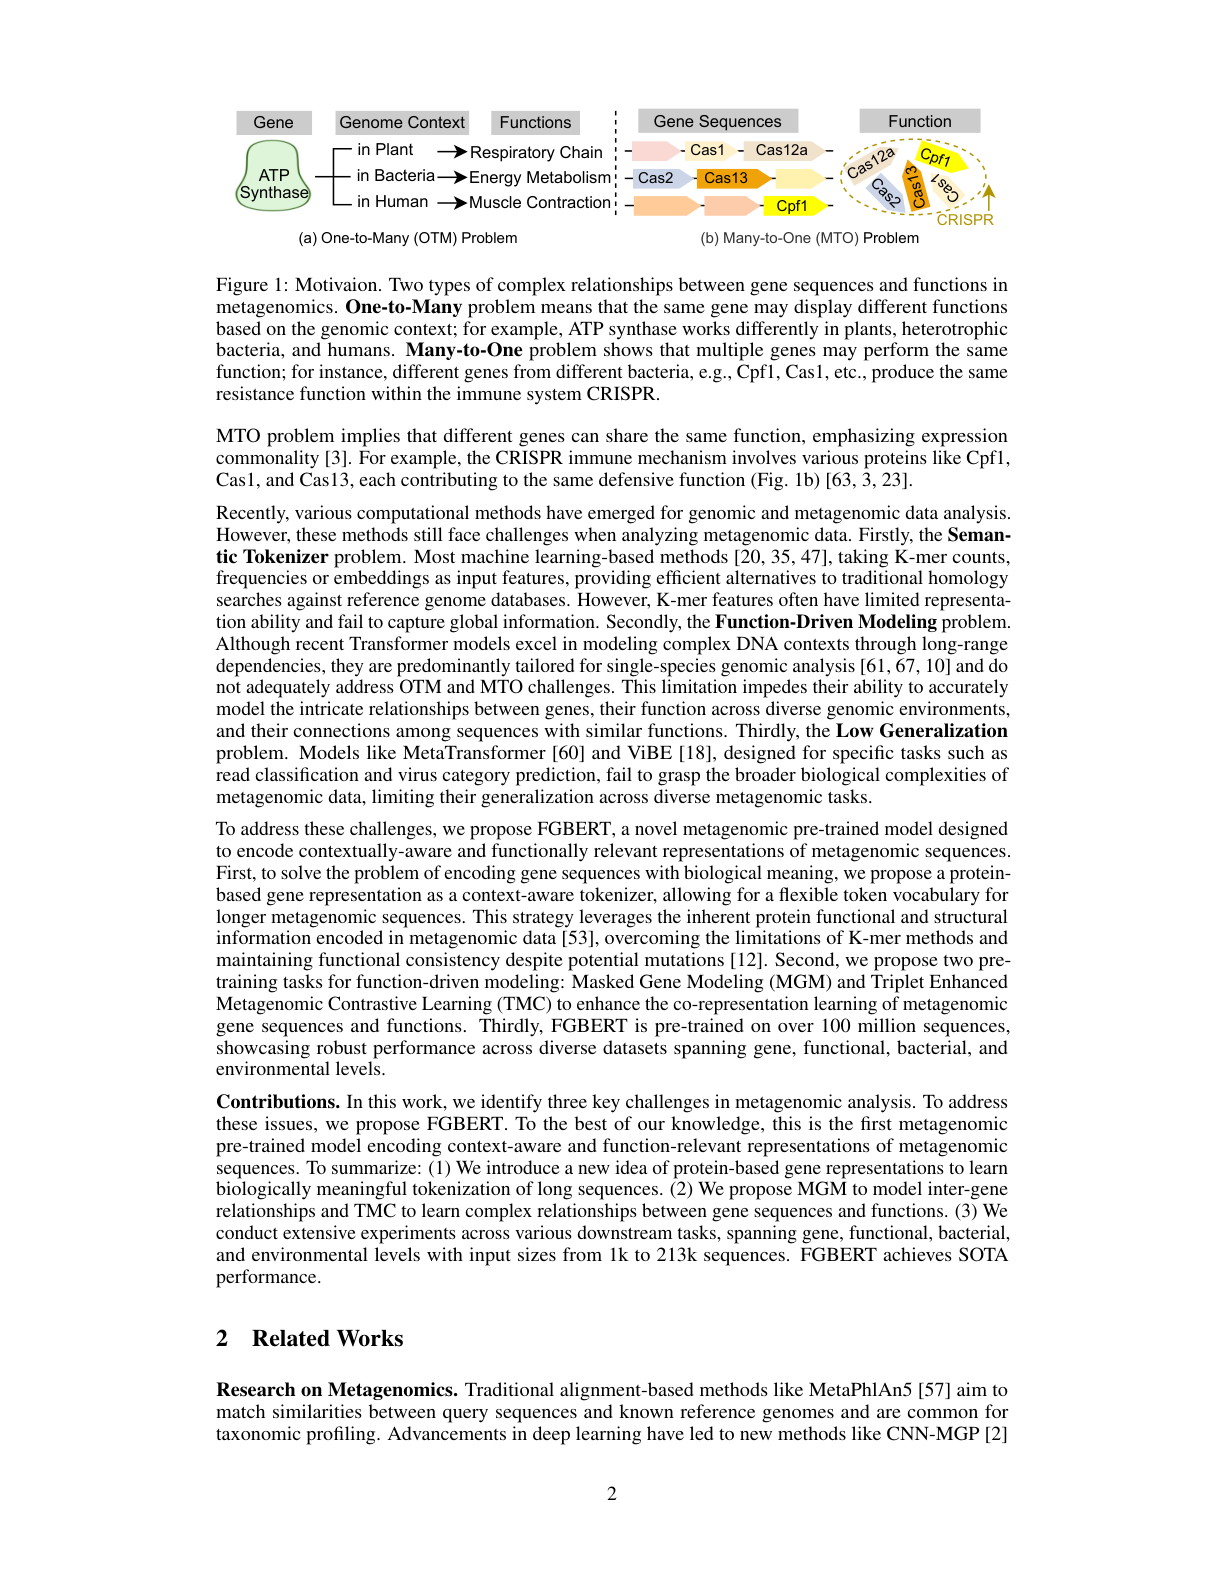

--- Page 3 ---


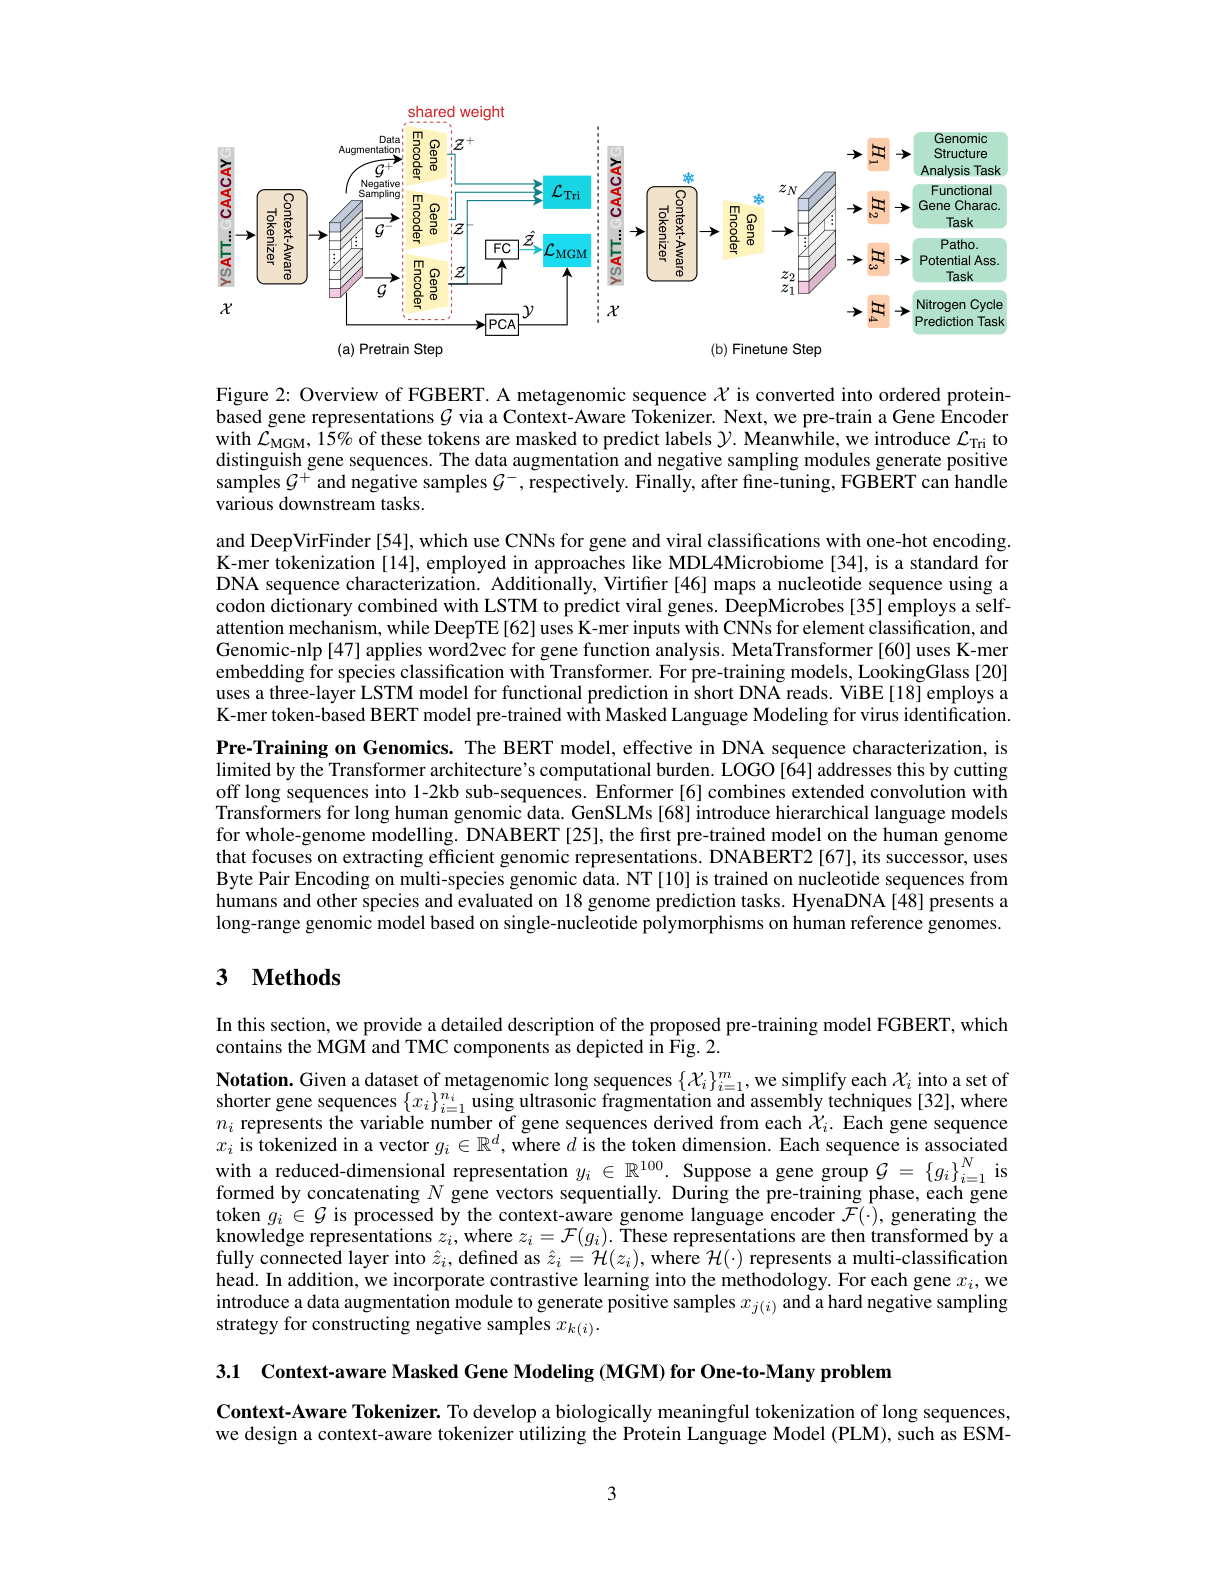

In [ ]:
import fitz  # PyMuPDF
import requests
from IPython.display import display, Image

paper_id = target_paper["id"]

# pdf_urls.json maps paper_id → arXiv PDF URL
pdf_url = pdf_urls.get(paper_id)
print(f"Downloading: {pdf_url}")

response = requests.get(pdf_url, timeout=30)
with open("/tmp/sample.pdf", "wb") as f:
    f.write(response.content)

# Render first 3 pages as PNG tiles — same as PixelRAG
doc = fitz.open("/tmp/sample.pdf")
for page_num in range(min(3, len(doc))):
    page = doc[page_num]
    mat = fitz.Matrix(2.0, 2.0)  # 2x zoom = ~144 DPI
    pix = page.get_pixmap(matrix=mat)
    png_bytes = pix.tobytes("png")
    print(f"--- Page {page_num + 1} ---")
    display(Image(data=png_bytes, width=650))

doc.close()

**Queries linked to this paper**

In [ ]:
# qrels maps query_id → {doc_id, section_id}
# Find all queries that point to our target paper
linked_query_ids = [
    qid for qid, rel in qrels.items()
    if rel["doc_id"] == paper_id
]

print(f"Queries linked to this paper: {len(linked_query_ids)}\n")
for qid in linked_query_ids[:5]:
    q = queries[qid]
    print(f"[{q['source']:20s}] [{q['type']:11s}]  {q['query'][:90]}")

Queries linked to this paper: 0



### Try PixelRAG

* https://github.com/StarTrail-org/PixelRAG
* Running through T4 GPU
* Notes 🍀
  * Have to install `pdf2image` to be able to use `pixelrag[pdf]`

In [ ]:
%pip install -q 'pixelrag[embed,index,serve,pdf]' pdf2image

import shutil
import subprocess
import sys

if sys.platform == "linux" and shutil.which("apt-get"):
    libs = (
        "libnss3 libatk-bridge2.0-0 libcups2 libdrm2 libxkbcommon0 "
        "libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libasound2 "
        "poppler-utils"
    )
    subprocess.run(f"apt-get -qq install -y {libs}", shell=True, check=False)

print("ready")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 932.0/932.0 kB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.6/166.6 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 19.9 MB/s eta 0:00:00
ready


**Render 5 PDFs to Screenshot Tiles**

In [ ]:
import os, json, subprocess
from pathlib import Path
import shutil
import sys
import re
import requests

# Ensure poppler-utils is installed. Already handled by muRfGIkLY9Ts, but good to ensure
if sys.platform == "linux" and shutil.which("apt-get"):
    subprocess.run("apt-get -qq update && apt-get -qq install -y poppler-utils", shell=True, check=False)

base = "/content/open_ragbench/pdf/arxiv"
tiles_root_dir = Path("/content/pixelrag_tiles") # Root for all tiles (extracted or original .png.tiles)
tiles_root_dir.mkdir(exist_ok=True)

extracted_tiles_dir = tiles_root_dir / "extracted" # This will be the input for chunk/embed
extracted_tiles_dir.mkdir(exist_ok=True, parents=True) # Ensure it exists

# Load pdf_urls to get arXiv PDF links
with open(f"{base}/pdf_urls.json") as f:
    pdf_urls = json.load(f)

# Pick 5 papers to test with
sample_ids = list(pdf_urls.keys())[:5]
pdf_dir = Path("/tmp/sample_pdfs")
pdf_dir.mkdir(exist_ok=True)

# Step 1: Download PDFs
for paper_id in sample_ids:
    pdf_path = pdf_dir / f"{paper_id}.pdf"
    if not pdf_path.exists():
        url = pdf_urls[paper_id]
        print(f"Downloading {paper_id}...")
        r = requests.get(url, timeout=30)
        pdf_path.write_bytes(r.content)

# Step 2: Convert each PDF to individual JPG tiles using pdftoppm
for paper_id in sample_ids:
    pdf_path = pdf_dir / f"{paper_id}.pdf"
    output_doc_dir = extracted_tiles_dir / paper_id
    output_doc_dir.mkdir(exist_ok=True)

    print(f"Converting {pdf_path} pages to JPGs in {output_doc_dir}...")
    try:
        # pdftoppm -jpeg -r 150 <input.pdf> <output_prefix>
        # -r 150 sets DPI to 150 (similar to pixelshot --dpi 150)
        subprocess.run(
            ["pdftoppm", "-jpeg", "-r", "150", str(pdf_path), str(output_doc_dir / paper_id)],
            check=True, capture_output=True, text=True
        )
        # Count the generated files
        n_tiles = len(list(output_doc_dir.glob(f"{paper_id}-*.jpg")))
        print(f"  Successfully converted {n_tiles} pages for {paper_id}")
    except subprocess.CalledProcessError as e:
        print(f"Error converting PDF {pdf_path}. Exit code: {e.returncode}")
        print("STDOUT:", e.stdout)
        print("STDERR:", e.stderr)
        raise
    except Exception as e:
        print(f"An unexpected error occurred during pdftoppm execution for {pdf_path}: {e}")
        raise

print(f"\nAll individual image tiles created in: {extracted_tiles_dir}")

Converting /tmp/sample_pdfs/2407.01528v3.pdf pages to JPGs in /content/pixelrag_tiles/extracted/2407.01528v3...
  Successfully converted 26 pages for 2407.01528v3
Converting /tmp/sample_pdfs/2412.00651v1.pdf pages to JPGs in /content/pixelrag_tiles/extracted/2412.00651v1...
  Successfully converted 21 pages for 2412.00651v1
Converting /tmp/sample_pdfs/2411.00713v1.pdf pages to JPGs in /content/pixelrag_tiles/extracted/2411.00713v1...
  Successfully converted 35 pages for 2411.00713v1
Converting /tmp/sample_pdfs/2411.16245v2.pdf pages to JPGs in /content/pixelrag_tiles/extracted/2411.16245v2...
  Successfully converted 6 pages for 2411.16245v2
Converting /tmp/sample_pdfs/2402.03953v4.pdf pages to JPGs in /content/pixelrag_tiles/extracted/2402.03953v4...
  Successfully converted 20 pages for 2402.03953v4

All individual image tiles created in: /content/pixelrag_tiles/extracted


**Display Sample Tiles**

--- 2407.01528v3-01.png ---


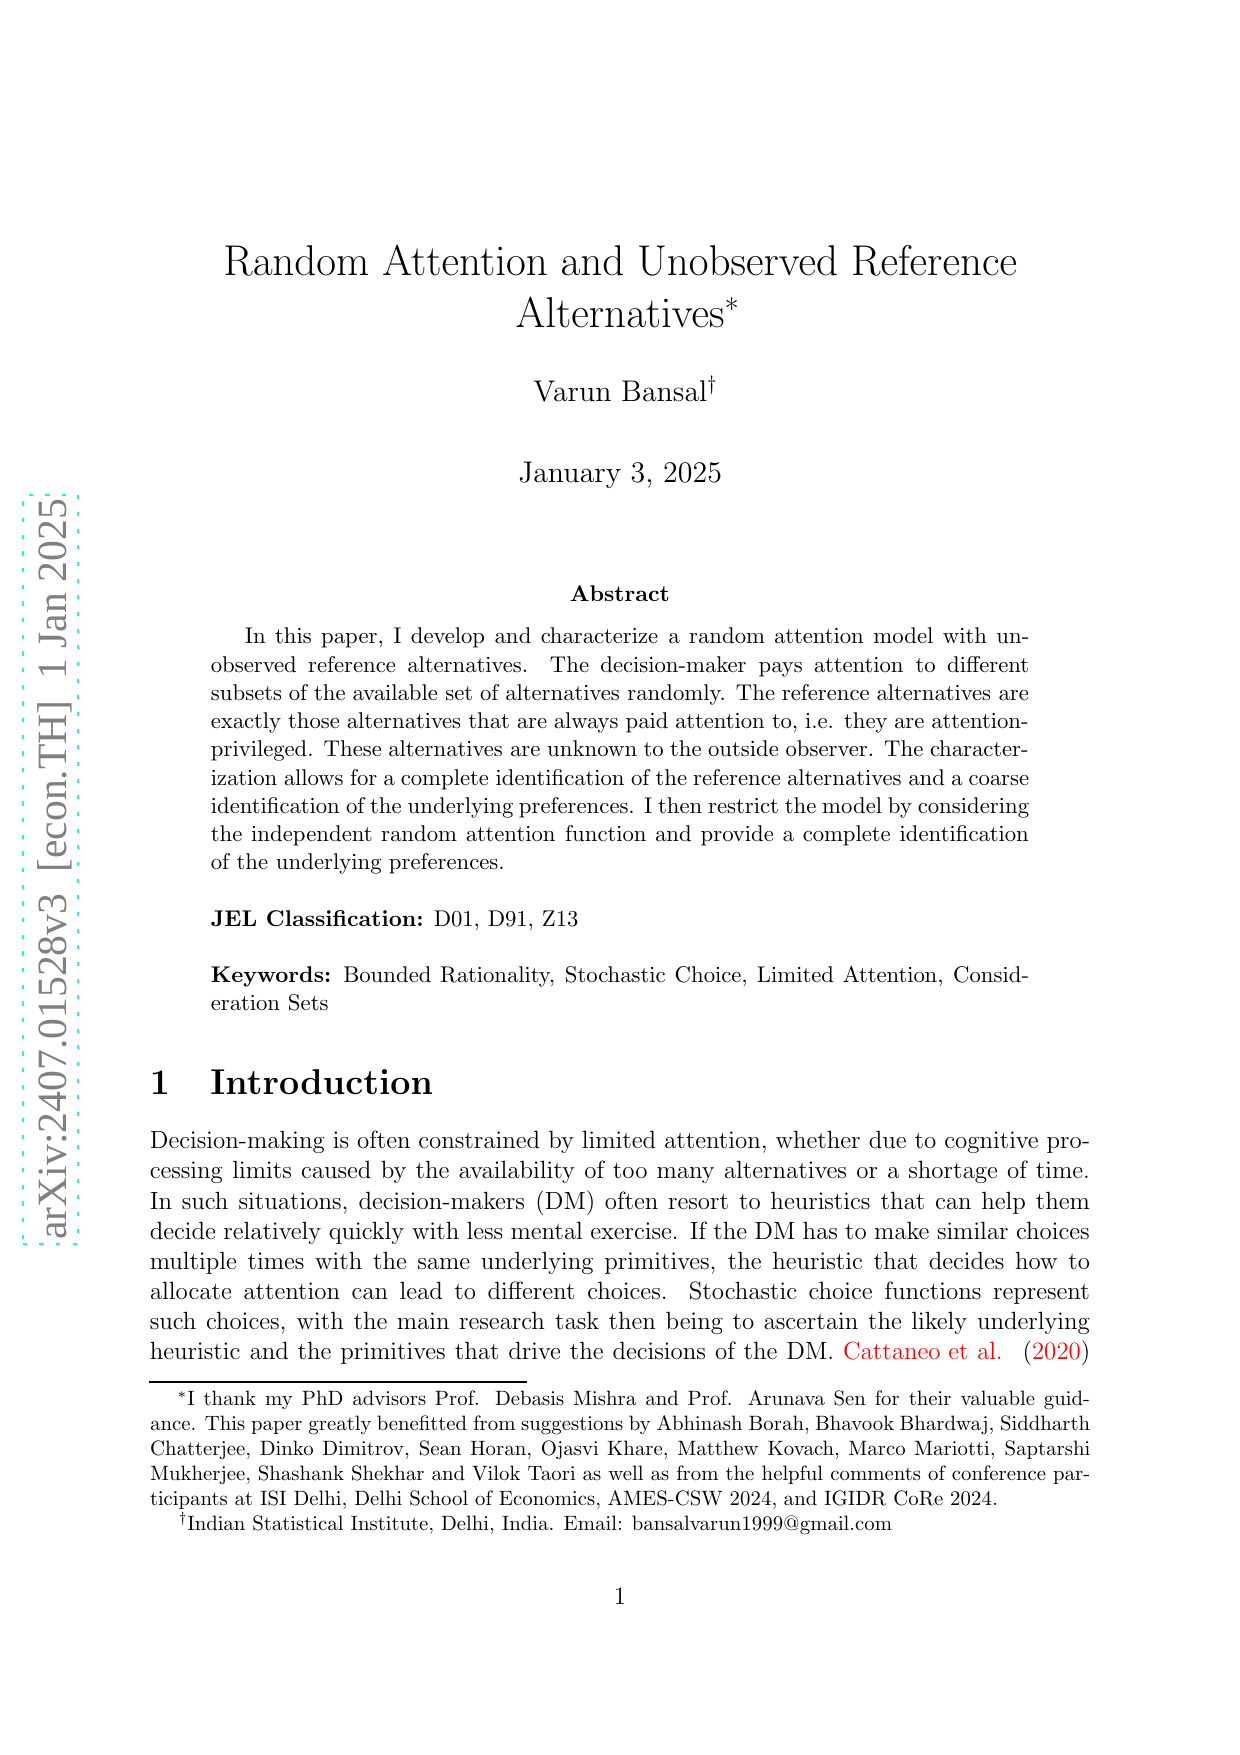

--- 2407.01528v3-02.png ---


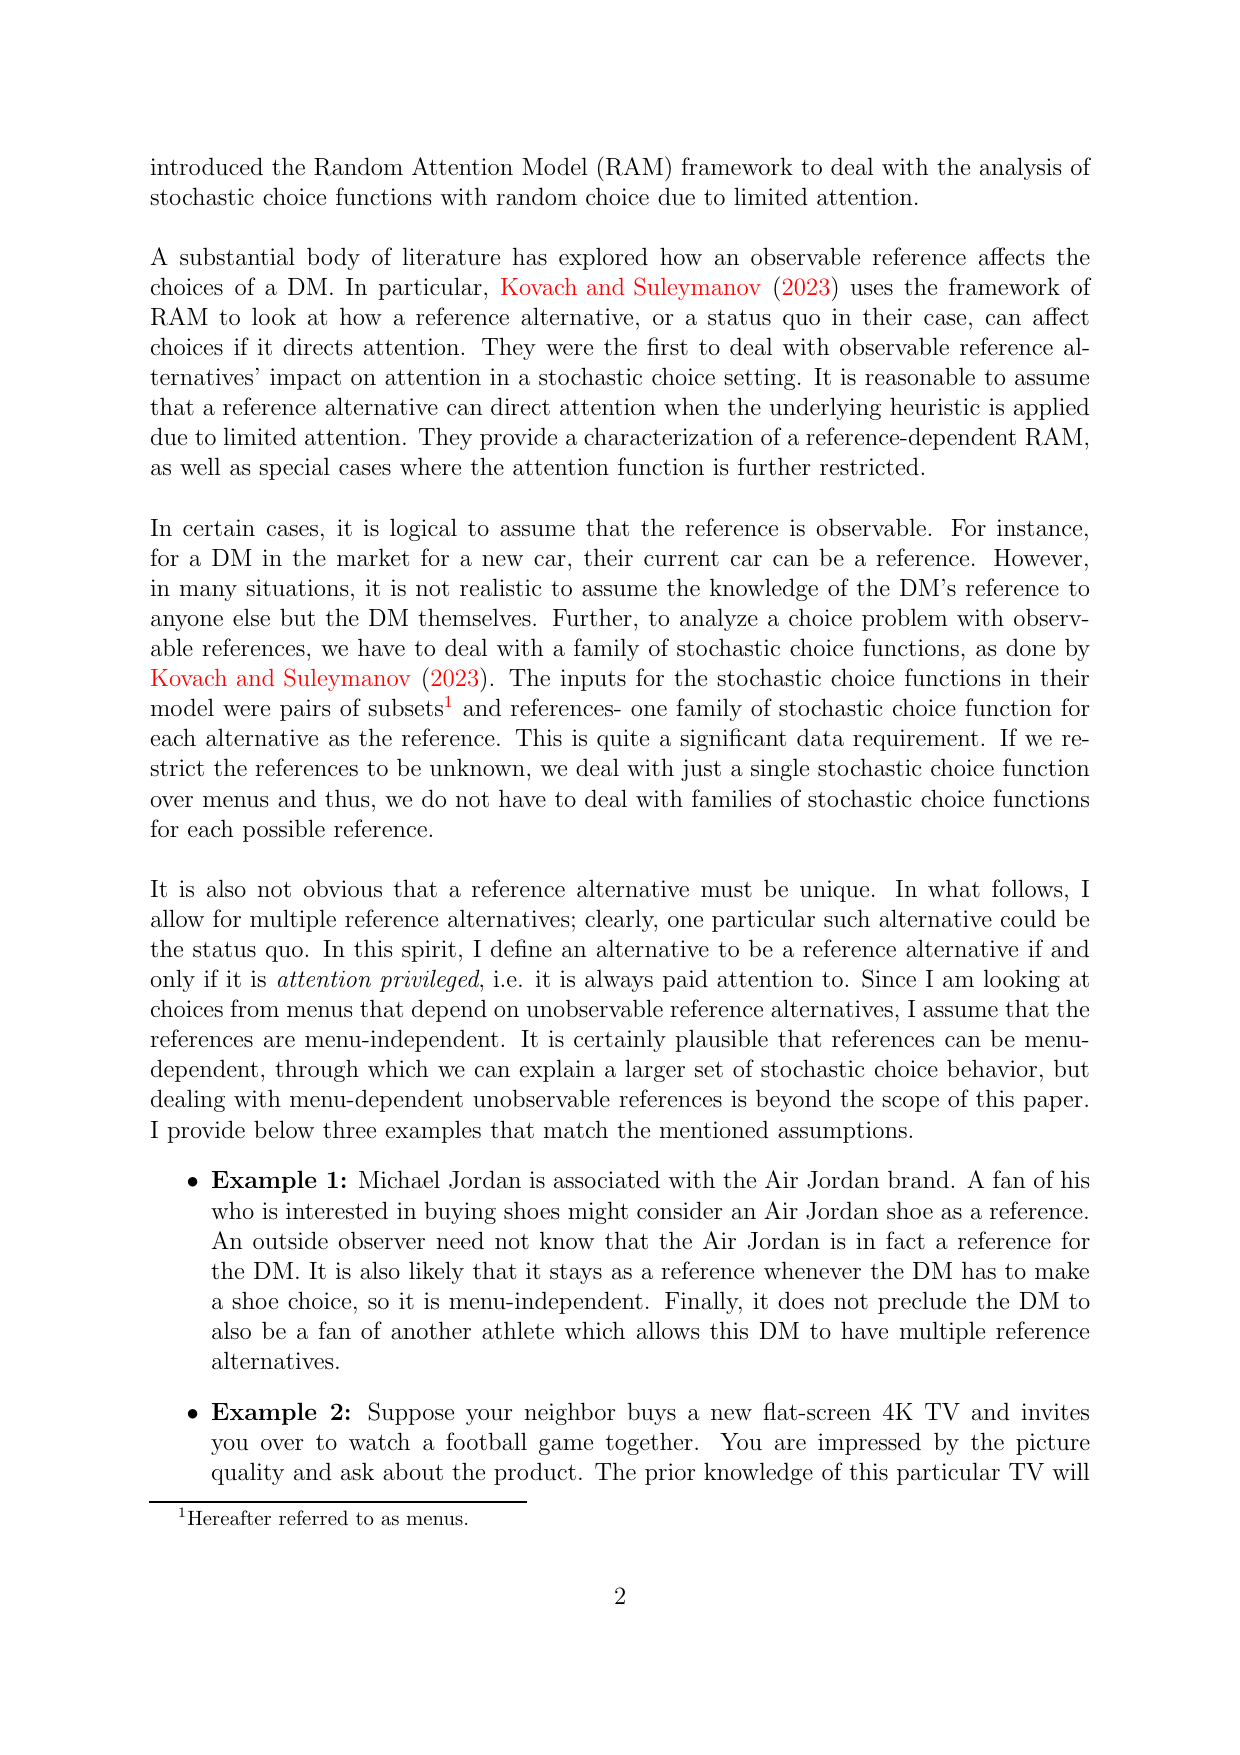

--- 2407.01528v3-03.png ---


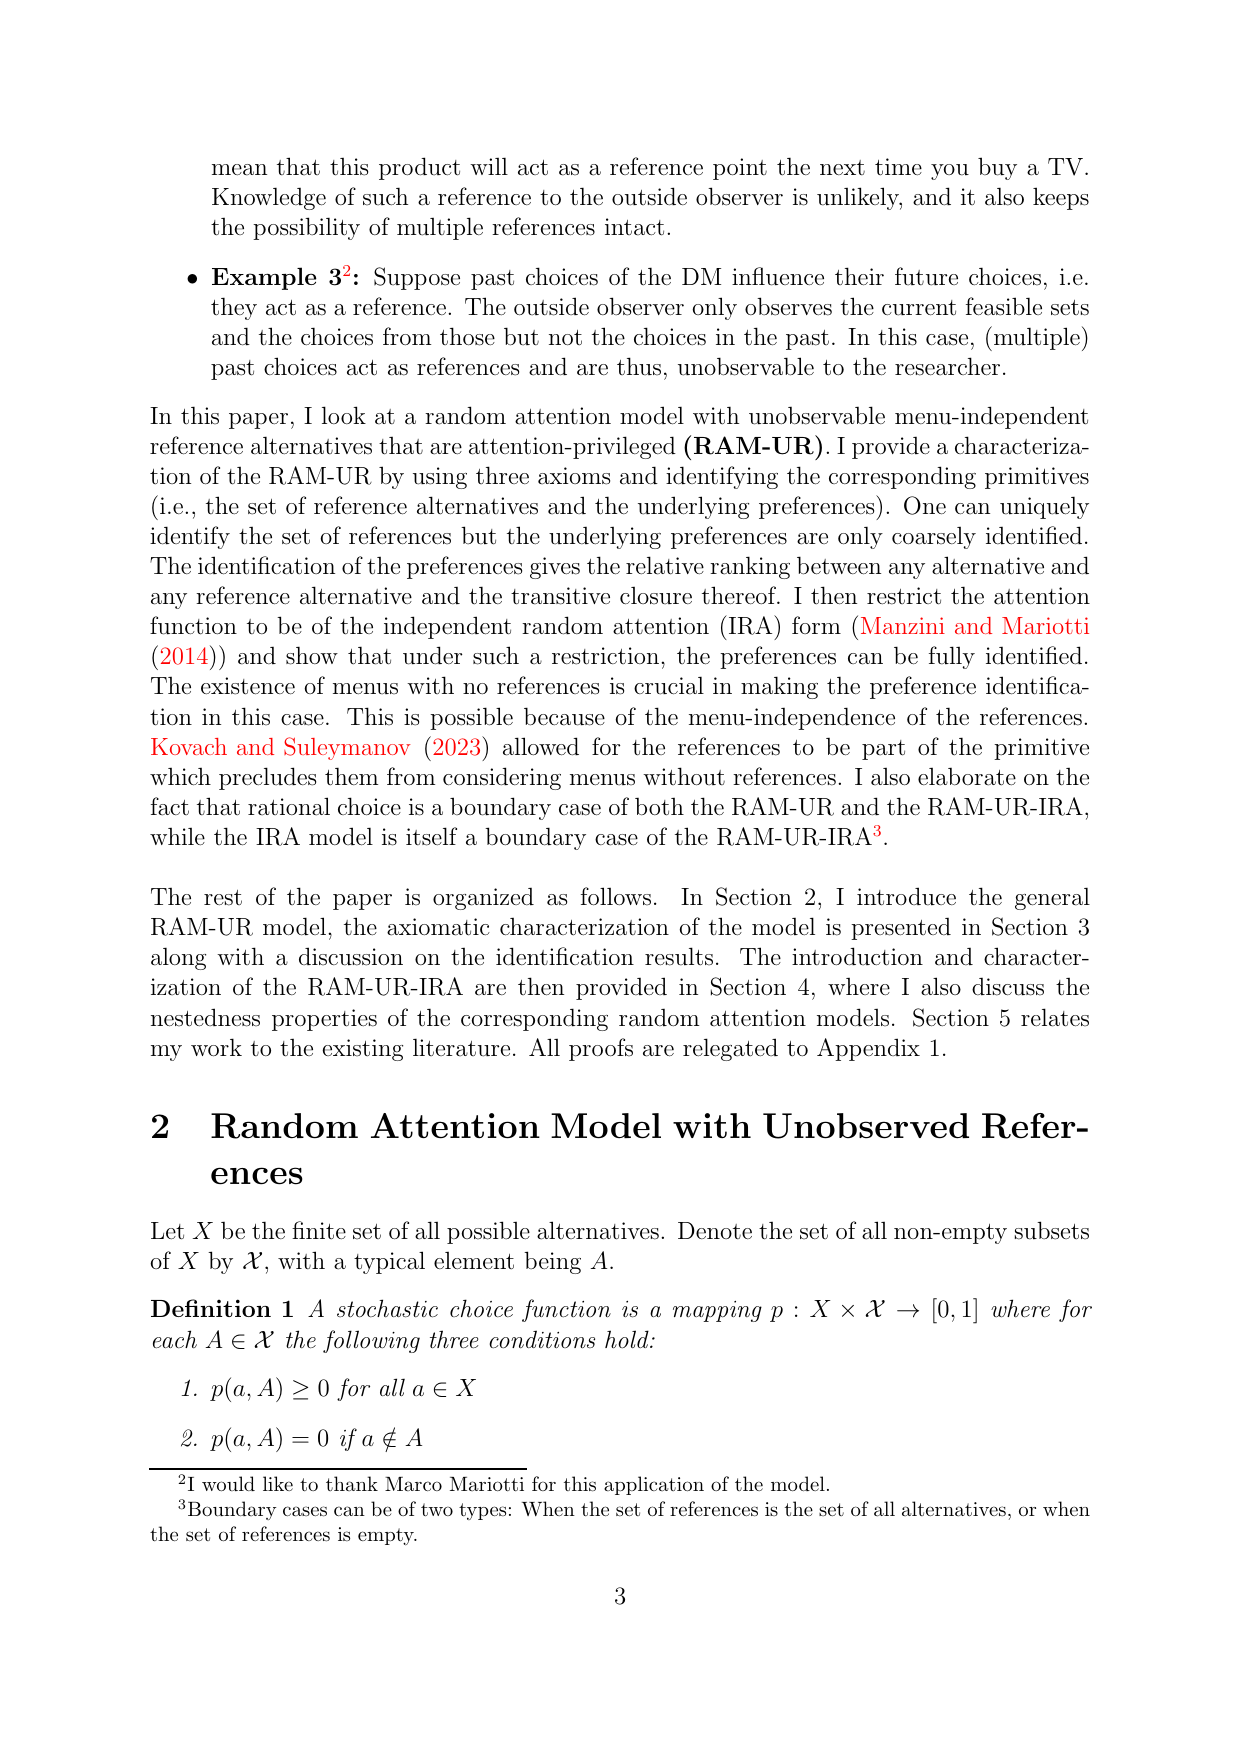

In [ ]:
from IPython.display import display, Image
import os
import subprocess
from pathlib import Path

# Show first 3 tiles from the first rendered paper
first_paper_id = sample_ids[0]
first_paper_pdf_path = pdf_dir / f"{first_paper_id}.pdf"
out_dir = tiles_dir / first_paper_id
out_dir.mkdir(exist_ok=True)

# Use pdftoppm to convert the first 3 pages of the PDF to PNG images
output_prefix = out_dir / first_paper_id

try:
    subprocess.run(
        ["pdftoppm", "-png", "-f", "1", "-l", "3", str(first_paper_pdf_path), str(output_prefix)],
        check=True, capture_output=True, text=True
    )
except subprocess.CalledProcessError as e:
    print(f"Error running pdftoppm for {first_paper_pdf_path}:\nSTDOUT: {e.stdout}\nSTDERR: {e.stderr}")
    raise
except Exception as e:
    print(f"An unexpected error occurred during pdftoppm execution for {first_paper_pdf_path}: {e}")
    raise

# Glob for the generated PNG files
glob_pattern = f"{output_prefix.name}-*.png"
tile_files = sorted(out_dir.glob(glob_pattern))

if not tile_files:
    print(f"Warning: No PNG files found in {out_dir} after pdftoppm with pattern {glob_pattern}.")

for tile_path in tile_files:
    print(f"--- {tile_path.name} ---")
    display(Image(filename=str(tile_path), width=650))

**Embed Chunk Tiles with Qwen3-VL-Embedding-2B**

In [ ]:
# chunk: assigns metadata (doc_id, tile_index) to each PNG
!pixelrag chunk --tiles-dir /content/pixelrag_tiles/extracted

# embed: runs Qwen3-VL-Embedding-2B over each tile shard
# --gpu-ids 0 uses the Colab T4; drop flag for CPU (slow)
!pixelrag embed \
    --shard-dir /content/pixelrag_tiles/extracted \
    --output-dir /content/pixelrag_embeddings \
    --gpu-ids 0

2026-06-29 05:59:44,219 - INFO - Found 0 shards in /content/pixelrag_tiles/extracted (workers=96, force=False, delete_tiles=False, dry_run=False)
2026-06-29 05:59:44,220 - INFO - Done: 0 shards, 0 articles chunked (0 skipped), 0 tiles → 0 chunks, 0 files written, 0 tiles deleted in 0s
2026-06-29 05:59:44,521 - embed_tiles - INFO - Embedding shard /content/pixelrag_tiles/extracted on GPUs [0]
2026-06-29 05:59:44,521 - embed_tiles - INFO - Scanned /content/pixelrag_tiles/extracted: 0 chunks from 0 articles
2026-06-29 05:59:44,521 - embed_tiles - WARNING - No chunks found in /content/pixelrag_tiles/extracted
2026-06-29 05:59:44,521 - embed_tiles - INFO - Done: {'shard_dir': '/content/pixelrag_tiles/extracted', 'output_path': '', 'num_tiles': 0, 'num_articles': 0, 'elapsed_s': 0.0004107952117919922}


**Build a FAISS IVF Index from Embeddings**

In [ ]:
!pixelrag build-index build \
    --embeddings-dir /content/pixelrag_embeddings \
    --output-dir /content/pixelrag_index

print("Index built at /content/pixelrag_index")

Found 0 shard files in /content/pixelrag_embeddings
No shard files found!
Index built at /content/pixelrag_index


**Start the PixelRAG Server**


**Inspect the Build Index**

In [ ]:
import os
from pathlib import Path

index_dir = Path("/content/pixelrag_index")
print("Index directory contents:")
for p in sorted(index_dir.rglob("*")):
    print(f"  {p.relative_to(index_dir)}  ({p.stat().st_size // 1024} KB)")

# Also check what pixelrag exposes at the top level
import pixelrag
print("\npixelrag public API:")
print([x for x in dir(pixelrag) if not x.startswith("_")])

Index directory contents:

pixelrag public API:
[]
